# IMPORTS

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, r2_score
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import shap
import pickle

c:\Users\bubut\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# GET DATA

In [2]:
left_features_df = pd.read_csv("dataset/processed/left_hand_features.csv")
# left_features_df = pd.DataFrame(left_features_df)
right_features_df = pd.read_csv("dataset/processed/right_hand_features.csv")
# right_features_df = pd.DataFrame(right_features_df)

In [3]:
left_features_df.head()

,num_taps,mean_peak_amp,std_peak_amp,amp_decrement,mean_iti,std_iti,cv_iti,num_long_pauses,prop_long_pauses,patient_id,hand,updrs,target
0,52,0.895847,0.043548,0.055189,0.542157,0.059807,0.110312,0,0.000000,C34,left,1,0
1,64,0.906656,0.050966,0.060950,0.452910,0.060022,0.132525,1,0.015873,C35,left,0,0
2,69,0.890518,0.125611,0.074415,0.420588,0.068068,0.161841,0,0.000000,C36,left,1,0
3,57,0.807915,0.192839,0.059099,0.522619,0.174785,0.334441,1,0.017857,C37,left,0,0
4,39,0.870205,0.111160,-0.050822,0.660088,0.189742,0.287450,1,0.026316,C38,left,0,0


In [4]:
right_features_df.head()

,num_taps,mean_peak_amp,std_peak_amp,amp_decrement,mean_iti,std_iti,cv_iti,num_long_pauses,prop_long_pauses,patient_id,hand,updrs,target
0,61,0.914892,0.047774,0.075582,0.467500,0.057205,0.122364,0,0.000000,C34,right,0,0
1,73,0.844620,0.148506,-0.074605,0.377778,0.105299,0.278734,4,0.055556,C35,right,0,0
2,60,0.951034,0.019800,0.014383,0.487006,0.054812,0.112550,0,0.000000,C36,right,0,0
3,26,0.934253,0.028889,0.023459,1.145333,0.244746,0.213689,1,0.040000,C37,right,0,0
4,36,0.925534,0.032226,-0.072683,0.778095,0.234648,0.301568,1,0.028571,C38,right,0,0


# MODEL TRAINING

In [5]:
# Prepare the data
X_left = left_features_df.drop(['patient_id', 'hand', 'updrs', 'target'], axis=1)
y_left = left_features_df['updrs']

# Split the data into training and testing sets
X_train_left, X_test_left, y_train_left, y_test_left = train_test_split(X_left, y_left, test_size=0.2, random_state=42)

# Scale the features
scaler_left = StandardScaler()
X_train_left = scaler_left.fit_transform(X_train_left)
X_test_left = scaler_left.transform(X_test_left)

import joblib
joblib.dump(scaler_left, "saved_models/left_scaler.pkl")


['saved_models/left_scaler.pkl']

In [6]:
# Prepare the data
X_right = right_features_df.drop(['patient_id', 'hand', 'updrs', 'target'], axis=1)
y_right = right_features_df['updrs']

# Split the data into training and testing sets
X_train_right, X_test_right, y_train_right, y_test_right = train_test_split(X_right, y_right, test_size=0.2, random_state=42)

# Scale the features
scaler_right = StandardScaler()
X_train_right = scaler_right.fit_transform(X_train_right)
X_test_right = scaler_right.transform(X_test_right)

joblib.dump(scaler_right, "saved_models/right_scaler.pkl")

['saved_models/right_scaler.pkl']

In [7]:
# ─────────────────────────────────────────────────────────────
# TENSORS
# ─────────────────────────────────────────────────────────────
X_train_left  = torch.tensor(np.asarray(X_train_left),  dtype=torch.float32)
X_test_left   = torch.tensor(np.asarray(X_test_left),   dtype=torch.float32)
y_train_left  = torch.tensor(np.asarray(y_train_left),  dtype=torch.long)
y_test_left   = torch.tensor(np.asarray(y_test_left),   dtype=torch.long)

X_train_right = torch.tensor(np.asarray(X_train_right), dtype=torch.float32)
X_test_right  = torch.tensor(np.asarray(X_test_right),  dtype=torch.float32)
y_train_right = torch.tensor(np.asarray(y_train_right), dtype=torch.long)
y_test_right  = torch.tensor(np.asarray(y_test_right),  dtype=torch.long)

# ─────────────────────────────────────────────────────────────
# DATASETS & LOADERS
# ─────────────────────────────────────────────────────────────
class UPDRSDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_left  = DataLoader(UPDRSDataset(X_train_left,  y_train_left),  batch_size=32, shuffle=True)
test_loader_left   = DataLoader(UPDRSDataset(X_test_left,   y_test_left),   batch_size=32, shuffle=False)
train_loader_right = DataLoader(UPDRSDataset(X_train_right, y_train_right), batch_size=32, shuffle=True)
test_loader_right  = DataLoader(UPDRSDataset(X_test_right,  y_test_right),  batch_size=32, shuffle=False)

In [8]:
# ─────────────────────────────────────────────────────────────
# MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────
class UPDRSModel(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ─────────────────────────────────────────────────────────────
# SHARED CONFIG — change once, applies to both sides
# ─────────────────────────────────────────────────────────────
N_EPOCHS   = 1000
LR         = 3e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES  = 3

criterion = nn.CrossEntropyLoss()  # same loss for both sides

# Initialise both models
left_model  = UPDRSModel(X_train_left.shape[1],  num_classes=NUM_CLASSES)
right_model = UPDRSModel(X_train_right.shape[1], num_classes=NUM_CLASSES)

# Each model needs its own optimizer (separate parameter sets)
optimizer_left  = optim.AdamW(left_model.parameters(),  lr=LR, weight_decay=WEIGHT_DECAY)
optimizer_right = optim.AdamW(right_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [9]:
# ─────────────────────────────────────────────────────────────
# TRAINING FUNCTION — write once, call twice
# ─────────────────────────────────────────────────────────────
def train_model(model, optimizer, train_loader, side):
    for epoch in range(N_EPOCHS):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch + 1) % 250 == 0:
            print(f"[{side}] Epoch [{epoch+1}/{N_EPOCHS}], Loss: {epoch_loss/len(train_loader):.4f}")

    print(f"\n✅ {side} side CNN trained successfully.")

# ─────────────────────────────────────────────────────────────
# TRAIN BOTH SIDES
# ─────────────────────────────────────────────────────────────
train_model(left_model,  optimizer_left,  train_loader_left,  side="Left")
train_model(right_model, optimizer_right, train_loader_right, side="Right")

[Left] Epoch [250/1000], Loss: 0.2105
[Left] Epoch [500/1000], Loss: 0.0541
[Left] Epoch [750/1000], Loss: 0.0219
[Left] Epoch [1000/1000], Loss: 0.0099

✅ Left side CNN trained successfully.
[Right] Epoch [250/1000], Loss: 0.4785
[Right] Epoch [500/1000], Loss: 0.3495
[Right] Epoch [750/1000], Loss: 0.2432
[Right] Epoch [1000/1000], Loss: 0.1873

✅ Right side CNN trained successfully.


### SVC, SVR, RF Classifier 

In [10]:
#### LEFT HAND

#SVC
svc_left = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
y_train_left = y_train_left.ravel()
y_test_left = y_test_left.ravel()
svc_left.fit(X_train_left, y_train_left)

#SVR
svr_left = SVR(kernel='rbf', C=1.0, gamma='scale')
svr_left.fit(X_train_left, y_train_left)

#RFC
rf_left = RandomForestClassifier(n_estimators=50, random_state=42)
rf_left.fit(X_train_left, y_train_left)



#### RIGHT HAND

#SVC
svc_right = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
y_train_right = y_train_right.ravel()
y_test_right = y_test_right.ravel()
svc_right.fit(X_train_right, y_train_right)

#SVR
svr_right = SVR(kernel='rbf', C=1.0, gamma='scale')
svr_right.fit(X_train_right, y_train_right)

# RFC
rf_right = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_right.fit(X_train_right, y_train_right)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Evaluation


  Random Forest — Left Side
  Accuracy:     0.6429
  Weighted F1:  0.6447

Classification Report:
                precision    recall  f1-score   support

    Mild (0-1)       0.71      0.62      0.67         8
Moderate (2-3)       0.57      0.67      0.62         6
    Severe (4)       0.00      0.00      0.00         0

      accuracy                           0.64        14
     macro avg       0.43      0.43      0.43        14
  weighted avg       0.65      0.64      0.64        14


  SVC — Left Side
  Accuracy:     0.7143
  Weighted F1:  0.7143

Classification Report:
                precision    recall  f1-score   support

    Mild (0-1)       0.75      0.75      0.75         8
Moderate (2-3)       0.67      0.67      0.67         6
    Severe (4)       0.00      0.00      0.00         0

      accuracy                           0.71        14
     macro avg       0.47      0.47      0.47        14
  weighted avg       0.71      0.71      0.71        14


  SVR — Left Side
  A

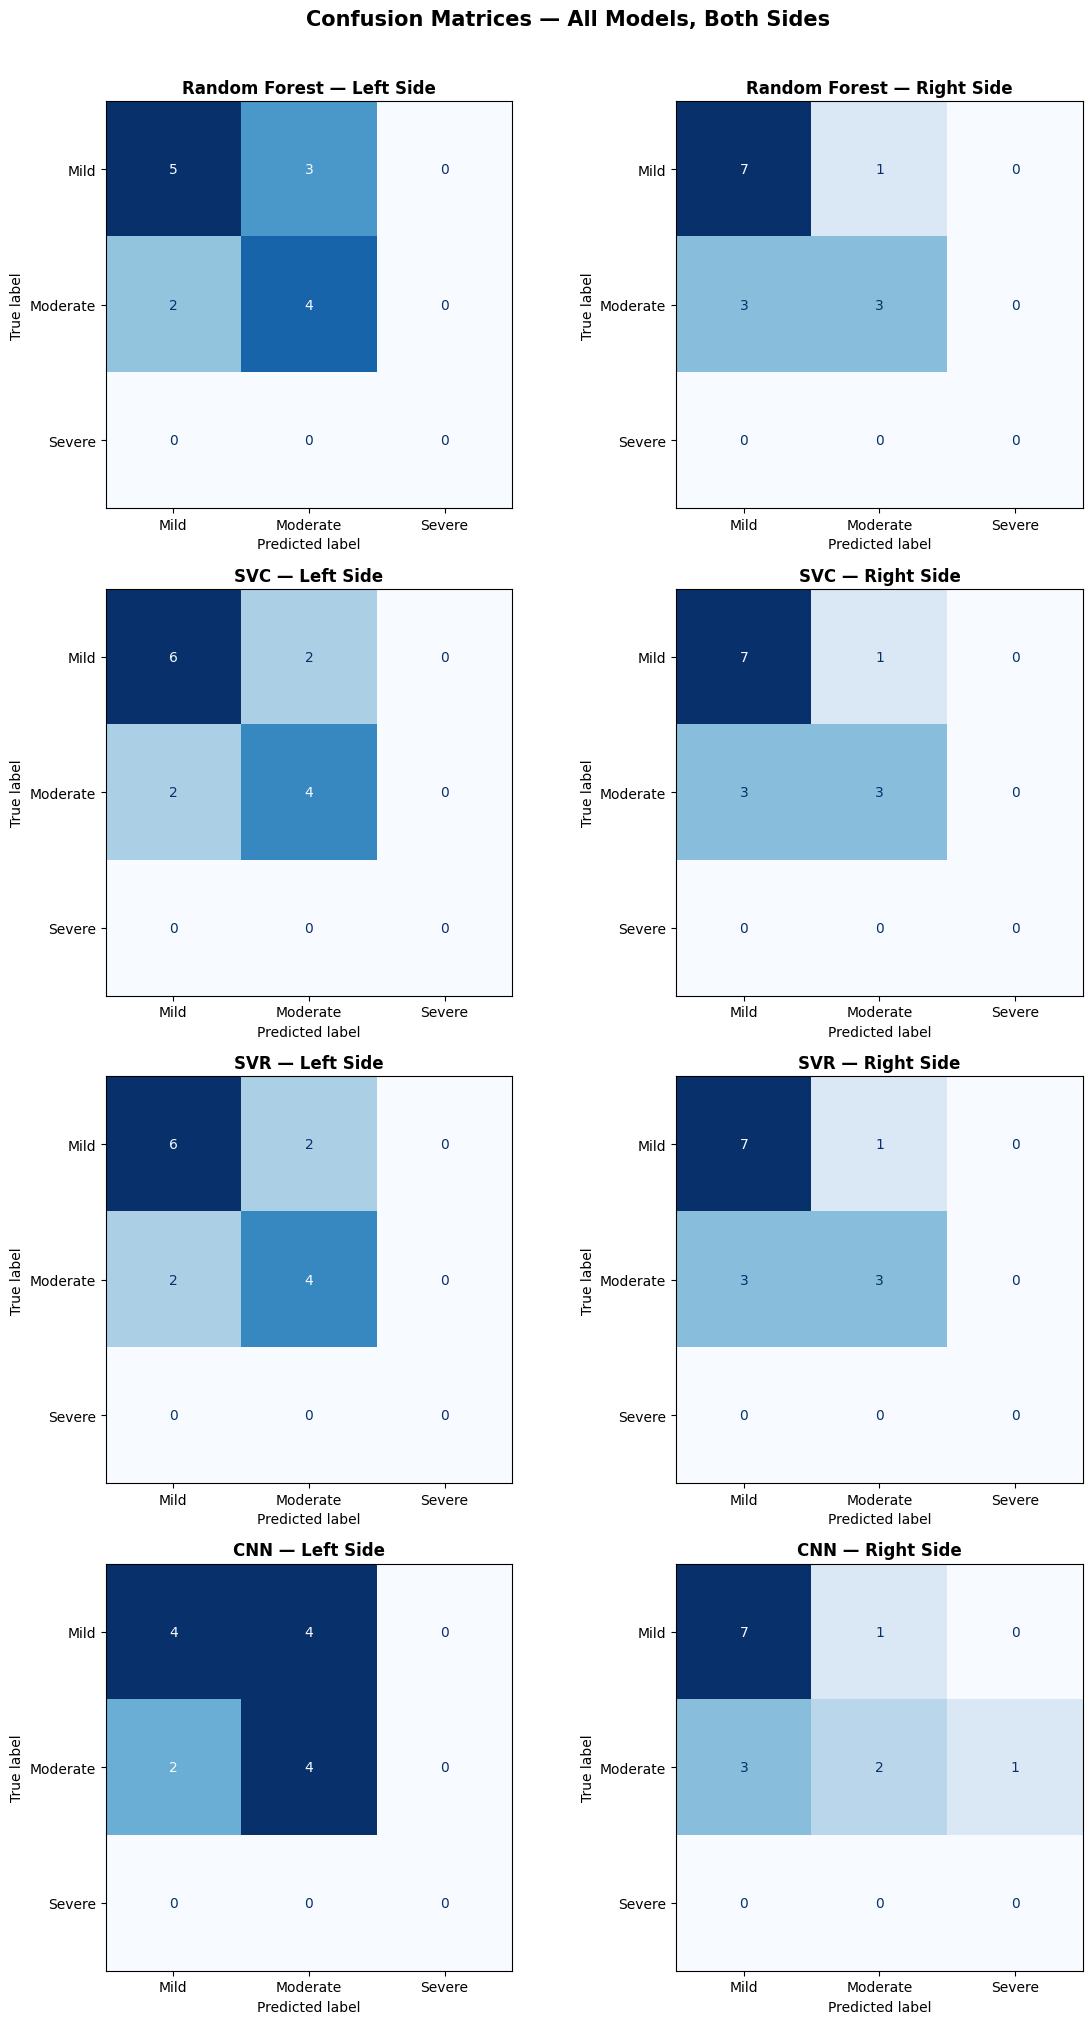

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────────────────────
# GROUND TRUTH — extract once, used by all models both sides
# .numpy() converts tensors back to numpy for sklearn
# ─────────────────────────────────────────────────────────────
y_true_left  = y_test_left.numpy()
y_true_right = y_test_right.numpy()

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION
# ─────────────────────────────────────────────────────────────
def evaluate_model(model_name, side, y_true, y_pred):
    print(f"\n{'='*55}")
    print(f"  {model_name} — {side} Side")
    print(f"{'='*55}")
    print(f"  Accuracy:     {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Weighted F1:  {f1_score(y_true, y_pred, average='weighted', labels=[0,1,2], zero_division=0):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                labels=[0, 1, 2],
                                target_names=['Mild (0-1)', 'Moderate (2-3)', 'Severe (4)'],
                                zero_division=0))

# ─────────────────────────────────────────────────────────────
# GET PREDICTIONS — ALL MODELS, BOTH SIDES
# sklearn needs numpy so we call .numpy() on the tensors
# ─────────────────────────────────────────────────────────────

# ── Random Forest ──────────────────────────────────────────
rf_pred_left  = rf_left.predict(X_test_left.numpy())
rf_pred_right = rf_right.predict(X_test_right.numpy())

# ── SVC ────────────────────────────────────────────────────
svc_pred_left  = svc_left.predict(X_test_left.numpy())
svc_pred_right = svc_right.predict(X_test_right.numpy())

# ── SVR (round + clip to get class labels) ─────────────────
svr_pred_left  = np.clip(np.round(svr_left.predict(X_test_left.numpy())),   0, 2).astype(int)
svr_pred_right = np.clip(np.round(svr_right.predict(X_test_right.numpy())), 0, 2).astype(int)

# ── CNN ────────────────────────────────────────────────────
def get_cnn_predictions(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            preds.extend(torch.argmax(outputs, dim=1).numpy())
    return np.array(preds)

cnn_pred_left  = get_cnn_predictions(left_model,  test_loader_left)
cnn_pred_right = get_cnn_predictions(right_model, test_loader_right)

# ─────────────────────────────────────────────────────────────
# PRINT ALL METRICS — 4 models x 2 sides
# ─────────────────────────────────────────────────────────────
for side, y_true, rf_pred, svc_pred, svr_pred, cnn_pred in [
    ("Left",  y_true_left,  rf_pred_left,  svc_pred_left,  svr_pred_left,  cnn_pred_left),
    ("Right", y_true_right, rf_pred_right, svc_pred_right, svr_pred_right, cnn_pred_right),
]:
    evaluate_model("Random Forest", side, y_true, rf_pred)
    evaluate_model("SVC",           side, y_true, svc_pred)
    evaluate_model("SVR",           side, y_true, svr_pred)
    evaluate_model("CNN",           side, y_true, cnn_pred)

# ─────────────────────────────────────────────────────────────
# CONFUSION MATRICES — 4 models x 2 sides = 8 plots
# ─────────────────────────────────────────────────────────────
models_info = [
    ("Random Forest", rf_pred_left,  rf_pred_right),
    ("SVC",           svc_pred_left, svc_pred_right),
    ("SVR",           svr_pred_left, svr_pred_right),
    ("CNN",           cnn_pred_left, cnn_pred_right),
]

class_labels = ['Mild', 'Moderate', 'Severe']
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle("Confusion Matrices — All Models, Both Sides", fontsize=15, fontweight='bold', y=1.01)

for row, (model_name, pred_left, pred_right) in enumerate(models_info):
    for col, (side, y_true, y_pred) in enumerate([
        ("Left",  y_true_left,  pred_left),
        ("Right", y_true_right, pred_right),
    ]):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
        disp.plot(ax=axes[row, col], cmap='Blues', colorbar=False)
        axes[row, col].set_title(f"{model_name} — {side} Side", fontweight='bold')

plt.tight_layout()
plt.savefig("all_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()


  Mutual Information Scores — Left Side
         Feature  MI Score
   amp_decrement  0.094935
   mean_peak_amp  0.067685
        mean_iti  0.040877
 num_long_pauses  0.032966
        num_taps  0.031490
          cv_iti  0.000721
    std_peak_amp  0.000000
         std_iti  0.000000
prop_long_pauses  0.000000


C:\Users\bubut\AppData\Local\Temp\ipykernel_20584\1087166295.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='MI Score', y='Feature', palette='Blues_r')


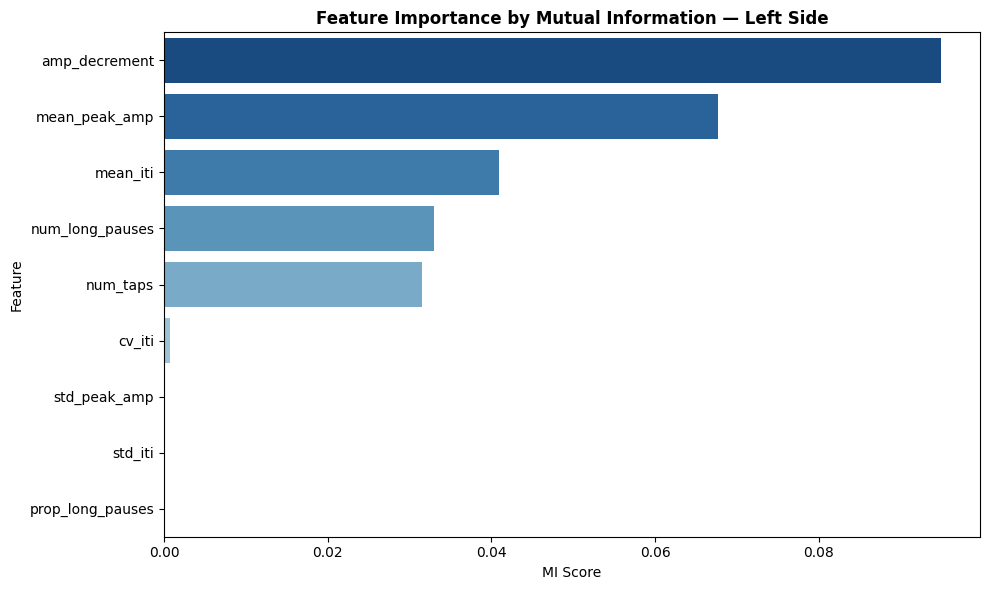


  Top 5 Selected Features:
    - num_taps
    - mean_peak_amp
    - amp_decrement
    - mean_iti
    - num_long_pauses

  Mutual Information Scores — Right Side
         Feature  MI Score
   mean_peak_amp  0.040649
    std_peak_amp  0.020161
          cv_iti  0.009160
 num_long_pauses  0.005923
        num_taps  0.000000
        mean_iti  0.000000
   amp_decrement  0.000000
         std_iti  0.000000
prop_long_pauses  0.000000


C:\Users\bubut\AppData\Local\Temp\ipykernel_20584\1087166295.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='MI Score', y='Feature', palette='Blues_r')


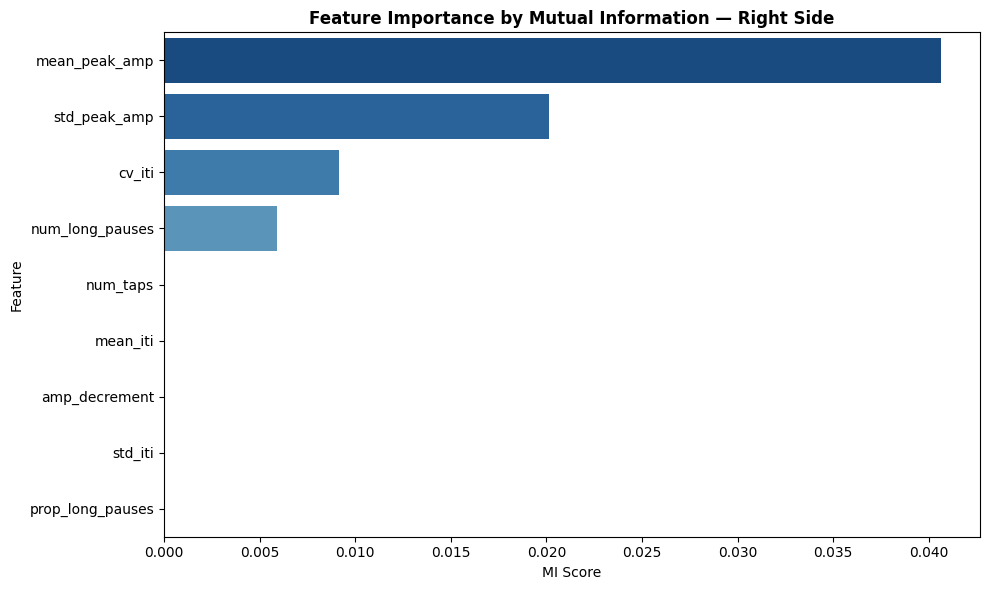


  Top 4 Selected Features:
    - mean_peak_amp
    - std_peak_amp
    - cv_iti
    - prop_long_pauses


In [12]:
# Feature Selection by Mutual Information
from sklearn.feature_selection import mutual_info_classif, SelectKBest
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────────────────────
# COMPUTE MUTUAL INFORMATION — BOTH SIDES
# ─────────────────────────────────────────────────────────────
def mutual_info_selection(X, y, side, k='all'):
    
    # Compute MI scores for all features
    mi_scores = mutual_info_classif(X, y, random_state=42)
    
    mi_df = pd.DataFrame({
        'Feature':  X.columns,
        'MI Score': mi_scores
    }).sort_values('MI Score', ascending=False).reset_index(drop=True)
    
    print(f"\n{'='*45}")
    print(f"  Mutual Information Scores — {side} Side")
    print(f"{'='*45}")
    print(mi_df.to_string(index=False))
    
    # ── Plot ───────────────────────────────────────────────
    plt.figure(figsize=(10, 6))
    sns.barplot(data=mi_df, x='MI Score', y='Feature', palette='Blues_r')
    plt.title(f"Feature Importance by Mutual Information — {side} Side", fontweight='bold')
    plt.xlabel("MI Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(f"saved_models/mi_scores_{side.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # ── Select top k features ──────────────────────────────
    if k != 'all':
        selector   = SelectKBest(mutual_info_classif, k=k)
        X_selected = selector.fit_transform(X, y)
        selected_features = X.columns[selector.get_support()].tolist()
        
        print(f"\n  Top {k} Selected Features:")
        for f in selected_features:
            print(f"    - {f}")
        
        return pd.DataFrame(X_selected, columns=selected_features), selected_features, mi_df
    
    return X, X.columns.tolist(), mi_df


# ─────────────────────────────────────────────────────────────
# RUN — BOTH SIDES
# ─────────────────────────────────────────────────────────────
X_left  = left_features_df.drop(columns=['target', 'patient_id', 'hand', 'updrs'])
y_left  = left_features_df['target']

X_right = right_features_df.drop(columns=['target', 'patient_id', 'hand', 'updrs'])
y_right = right_features_df['target']

# Change k to however many features you want to keep
# k='all' shows scores without dropping anything
X_left_selected,  left_features,  mi_left  = mutual_info_selection(X_left,  y_left,  side="Left",  k=5)
X_right_selected, right_features, mi_right = mutual_info_selection(X_right, y_right, side="Right", k=4)


  Random Forest — Left Side
Fitting 5 folds for each of 50 candidates, totalling 250 fits

  Best Weighted F1: 0.9105
  Best Params:      {'rf__n_estimators': 300, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_features': None, 'rf__max_depth': 30, 'rf__class_weight': None}
  Accuracy:         0.9394


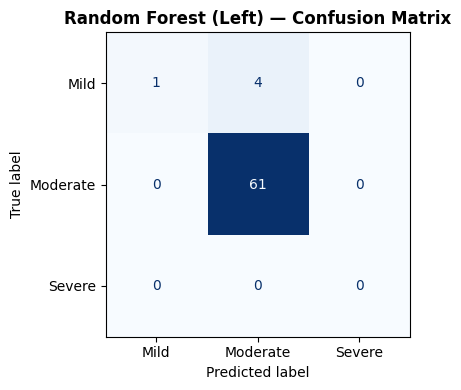

  ✅  Saved: saved_models/rf_left.pkl

  Random Forest — Right Side
Fitting 5 folds for each of 50 candidates, totalling 250 fits

  Best Weighted F1: 0.8878
  Best Params:      {'rf__n_estimators': 100, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 4, 'rf__max_features': 'log2', 'rf__max_depth': 30, 'rf__class_weight': None}
  Accuracy:         0.9242


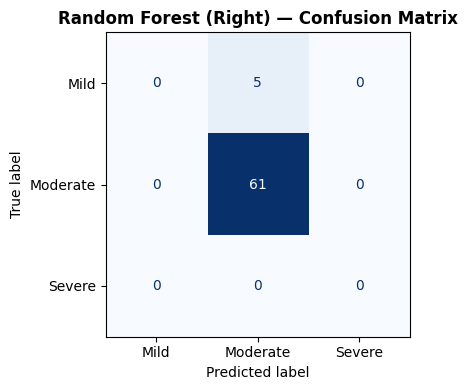

  ✅  Saved: saved_models/rf_right.pkl

  SVC — Left Side
Fitting 5 folds for each of 50 candidates, totalling 250 fits

  Best Weighted F1: 0.8884
  Best Params:      {'svc__kernel': 'linear', 'svc__gamma': 'scale', 'svc__degree': 4, 'svc__class_weight': 'balanced', 'svc__C': 100}
  Accuracy:         0.8636


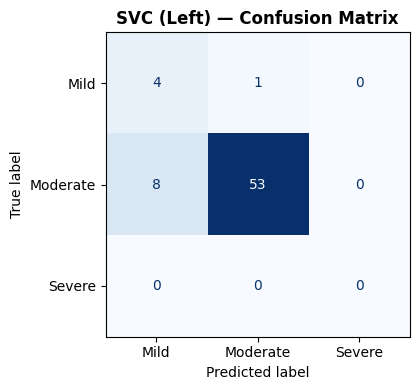

  ✅  Saved: saved_models/svc_left.pkl

  SVC — Right Side
Fitting 5 folds for each of 50 candidates, totalling 250 fits

  Best Weighted F1: 0.8878
  Best Params:      {'svc__kernel': 'poly', 'svc__gamma': 'scale', 'svc__degree': 2, 'svc__class_weight': None, 'svc__C': 10}
  Accuracy:         0.9242


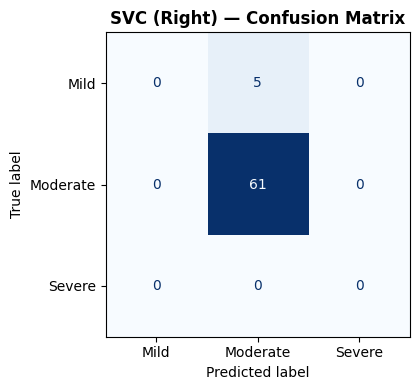

  ✅  Saved: saved_models/svc_right.pkl

  SVR — Left Side
Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\bubut\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



  Best Weighted F1: nan
  Best Params:      {'svr__kernel': 'linear', 'svr__gamma': 0.01, 'svr__epsilon': 0.1, 'svr__C': 0.5}
  Accuracy:         0.9242
  ✅  Saved: saved_models/svr_left.pkl

  SVR — Right Side
Fitting 5 folds for each of 50 candidates, totalling 250 fits

  Best Weighted F1: nan
  Best Params:      {'svr__kernel': 'linear', 'svr__gamma': 0.01, 'svr__epsilon': 0.1, 'svr__C': 0.5}
  Accuracy:         0.9242
  ✅  Saved: saved_models/svr_right.pkl
Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(max_depth=30, max_features=None,
                                        min_samples_split=5, n_estimators=300,
                                        random_state=42))])
Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(max_depth=30, max_features='log2',
                                        min_samples_leaf=4, random_state=42))])
Pipeline(steps=[('scaler', S

c:\Users\bubut\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [13]:
# ─────────────────────────────────────────────────────────────
# PARAM GRIDS
# ─────────────────────────────────────────────────────────────
rf_params = {
    'rf__n_estimators':      [100, 200, 300, 500],
    'rf__max_depth':         [None, 5, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf':  [1, 2, 4],
    'rf__max_features':      ['sqrt', 'log2', None],
    'rf__class_weight':      ['balanced', 'balanced_subsample', None],
}

svc_params = {
    'svc__C':          [0.01, 0.1, 0.5, 1, 5, 10, 100],
    'svc__kernel':     ['rbf', 'linear', 'poly'],
    'svc__gamma':      ['scale', 'auto', 0.001, 0.01, 0.1],
    'svc__degree':     [2, 3, 4],          # only used when kernel='poly'
    'svc__class_weight': ['balanced', None],
}

svr_params = {
    'svr__C':       [0.01, 0.1, 0.5, 1, 5, 10, 100],
    'svr__kernel':  ['rbf', 'linear', 'poly'],
    'svr__gamma':   ['scale', 'auto', 0.001, 0.01, 0.1],
    'svr__epsilon': [0.01, 0.1, 0.2, 0.5],
}

# ─────────────────────────────────────────────────────────────
# PIPELINES
# ─────────────────────────────────────────────────────────────
rf_pipeline  = Pipeline([('scaler', StandardScaler()), ('rf',  RandomForestClassifier(random_state=42))])
svc_pipeline = Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=42))])
svr_pipeline = Pipeline([('scaler', StandardScaler()), ('svr', SVR())])


def run_random_search(pipeline, param_grid, X, y, model_name, side, model_type, n_iter=50):
    """
    model_type: 'rf', 'svc', or 'svr'
    """
    print(f"\n{'='*55}")
    print(f"  {model_name} — {side} Side")
    print(f"{'='*55}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring='f1_weighted',
        cv=skf,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X, y)

    print(f"\n  Best Weighted F1: {search.best_score_:.4f}")
    print(f"  Best Params:      {search.best_params_}")

    # ── Cross-validated predictions ────────────────────────
    y_pred = cross_val_predict(search.best_estimator_, X, y, cv=skf)

    # SVR outputs continuous values e.g. 1.73 — round to nearest class
    if model_type == 'svr':
        y_pred = np.clip(np.round(y_pred), 0, 2).astype(int)

    # ── Accuracy ──────────────────────────────────────────
    print(f"  Accuracy:         {accuracy_score(y, y_pred):.4f}")

    # ── Confusion Matrix — skip for SVR ───────────────────
    if model_type != 'svr':
        cm   = confusion_matrix(y, y_pred, labels=[0, 1, 2])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Mild', 'Moderate', 'Severe'])
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"{model_name} ({side}) — Confusion Matrix", fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"img/confusion_{model_type}_{side.lower()}.png", dpi=150)
        plt.show()
        plt.close()

    # ── Extract scaler and raw model from pipeline ─────────
    scaler      = search.best_estimator_.named_steps['scaler']
    raw_model   = search.best_estimator_.named_steps[model_type]
    X_scaled    = scaler.transform(X)

    # # ── SHAP values ────────────────────────────────────────
    # max_display=len(X.columns)  # always shows all features regardless of count
    # if model_type == 'rf':
    #     # TreeExplainer — fast, works directly on RF
    #     explainer   = shap.TreeExplainer(raw_model)
    #     shap_values = explainer.shap_values(X_scaled)

    #     shap.summary_plot(shap_values, X_scaled, feature_names=X.columns.tolist(), max_display=max_display, show=True)
    #     plt.savefig(f"img/shap_{model_type}_{side.lower()}.png", dpi=150, bbox_inches='tight')
    #     plt.close()

    # elif model_type == 'svc':
    #     # KernelExplainer — slower, use a background sample
    #     background  = shap.kmeans(X_scaled, 10)
    #     explainer   = shap.KernelExplainer(raw_model.predict_proba, background)
    #     shap_values = explainer.shap_values(X_scaled[:50])

    #     shap.summary_plot(shap_values, X_scaled[:50], feature_names=X.columns.tolist(), max_display=max_display, show=True)
    #     plt.savefig(f"img/shap_{model_type}_{side.lower()}.png", dpi=150, bbox_inches='tight')
    #     plt.close()

    # else:
    #     # SVR — skip SHAP entirely
    #     print(f"  ⚠️  SHAP skipped for SVR")

    # ── Save model to pickle ───────────────────────────────
    save_path = f"saved_models/{model_type}_{side.lower()}.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(search.best_estimator_, f)
    print(f"  ✅  Saved: {save_path}")

    return search.best_estimator_


# ─────────────────────────────────────────────────────────────
# RUN — ALL MODELS, BOTH SIDES
# ─────────────────────────────────────────────────────────────
rf_left   = run_random_search(rf_pipeline,  rf_params,  X_left_selected,  y_left,  "Random Forest", "Left",  model_type='rf')
rf_right  = run_random_search(rf_pipeline,  rf_params,  X_right_selected, y_right, "Random Forest", "Right", model_type='rf')

svc_left  = run_random_search(svc_pipeline, svc_params, X_left_selected,  y_left,  "SVC", "Left",  model_type='svc')
svc_right = run_random_search(svc_pipeline, svc_params, X_right_selected, y_right, "SVC", "Right", model_type='svc')

svr_left  = run_random_search(svr_pipeline, svr_params, X_left_selected,  y_left,  "SVR", "Left",  model_type='svr')
svr_right = run_random_search(svr_pipeline, svr_params, X_right_selected, y_right, "SVR", "Right", model_type='svr')

print(rf_left)
print(rf_right)
print(svc_left)
print(svc_right)
print(svr_left)
print(svr_right)

In [18]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix


# ─────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────
class UPDRSModel(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# ─────────────────────────────────────────────
# OBJECTIVE (VALIDATION SPLIT)
# ─────────────────────────────────────────────
def objective(trial, X, y):

    lr           = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [16, 32, 64])
    hidden_dim1  = trial.suggest_categorical('hidden_dim1', [32, 64, 128])
    hidden_dim2  = trial.suggest_categorical('hidden_dim2', [16, 32, 64])
    n_epochs     = trial.suggest_int('n_epochs', 100, 300, step=50)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_tr = torch.tensor(X_train.values, dtype=torch.float32)
    y_tr = torch.tensor(y_train.values, dtype=torch.long)
    X_va = torch.tensor(X_val.values, dtype=torch.float32)
    y_va = torch.tensor(y_val.values, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=batch_size,
        shuffle=True
    )

    model = UPDRSModel(
        input_dim=X_tr.shape[1],
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # TRAIN
    model.train()
    for _ in range(n_epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    # VALIDATE
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_va), dim=1).numpy()

    return f1_score(y_va.numpy(), preds, average='weighted', zero_division=0)


# ─────────────────────────────────────────────
# RUN OPTUNA
# ─────────────────────────────────────────────
def run_search(X, y, n_trials=50):

    study = optuna.create_study(direction='maximize')
    study.optimize(
        lambda trial: objective(trial, X, y),
        n_trials=n_trials,
        show_progress_bar=True
    )

    print("\nBest F1:", study.best_value)
    print("Best Params:", study.best_params)

    return study.best_params


# ─────────────────────────────────────────────
# FINAL TRAINING + METRICS
# ─────────────────────────────────────────────
def train_final_model(X, y, best_params, side=""):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_tr = torch.tensor(X_train.values, dtype=torch.float32)
    y_tr = torch.tensor(y_train.values, dtype=torch.long)
    X_te = torch.tensor(X_test.values, dtype=torch.float32)
    y_te = torch.tensor(y_test.values, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=best_params['batch_size'],
        shuffle=True
    )

    model = UPDRSModel(
        input_dim=X_tr.shape[1],
        hidden_dim1=best_params['hidden_dim1'],
        hidden_dim2=best_params['hidden_dim2']
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay']
    )

    criterion = nn.CrossEntropyLoss()

    # TRAIN
    model.train()
    for _ in range(best_params['n_epochs']):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    # EVALUATE
    model.eval()
    with torch.no_grad():
        logits = model(X_te)
        preds = torch.argmax(logits, dim=1).numpy()

    y_true = y_te.numpy()

    weighted_f1 = f1_score(y_true, preds, average='weighted', zero_division=0)
    accuracy   = accuracy_score(y_true, preds)
    cm         = confusion_matrix(y_true, preds)

    print(f"\n{'='*40}")
    print(f"{side} Model Performance")
    print(f"{'='*40}")
    print("Weighted F1 :", round(weighted_f1, 4))
    print("Accuracy    :", round(accuracy, 4))
    print("Conf Matrix :\n", cm)

    return model


# ─────────────────────────────────────────────
# RUN BOTH SIDES
# ─────────────────────────────────────────────
best_left  = run_search(X_left_selected,  y_left,  n_trials=10)
best_right = run_search(X_right_selected, y_right, n_trials=10)

left_model  = train_final_model(X_left_selected,  y_left,  best_left,  side="Left")
right_model = train_final_model(X_right_selected, y_right, best_right, side="Right")


# ─────────────────────────────────────────────
# PREDICTIONS
# ─────────────────────────────────────────────
def get_predictions(model, X):
    X_tensor = torch.tensor(X.values, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_tensor), dim=1).numpy()
    return preds


# cnn_pred_left  = get_predictions(left_model,  X_left_selected)
# cnn_pred_right = get_predictions(right_model, X_right_selected)
get_predictions(left_model,  X_left_selected)
get_predictions(right_model, X_right_selected)

[I 2026-03-27 20:21:27,302] A new study created in memory with name: no-name-da40b8a3-dd8d-4d59-bdf7-fd48b0961c07
Best trial: 0. Best value: 0.89418:  10%|█         | 1/10 [00:00<00:03,  2.69it/s]

[I 2026-03-27 20:21:27,672] Trial 0 finished with value: 0.8941798941798941 and parameters: {'lr': 0.0011429162485182443, 'weight_decay': 0.0008113267786525195, 'batch_size': 32, 'hidden_dim1': 64, 'hidden_dim2': 32, 'n_epochs': 100}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  20%|██        | 2/10 [00:00<00:02,  3.60it/s]

[I 2026-03-27 20:21:27,885] Trial 1 finished with value: 0.8941798941798941 and parameters: {'lr': 0.00011789428811953685, 'weight_decay': 4.143388524167685e-06, 'batch_size': 64, 'hidden_dim1': 64, 'hidden_dim2': 64, 'n_epochs': 100}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  30%|███       | 3/10 [00:01<00:03,  2.32it/s]

[I 2026-03-27 20:21:28,497] Trial 2 finished with value: 0.8941798941798941 and parameters: {'lr': 0.00022049528785979383, 'weight_decay': 1.319336975251925e-06, 'batch_size': 64, 'hidden_dim1': 128, 'hidden_dim2': 16, 'n_epochs': 250}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  40%|████      | 4/10 [00:02<00:03,  1.51it/s]

[I 2026-03-27 20:21:29,510] Trial 3 finished with value: 0.8941798941798941 and parameters: {'lr': 0.0001254148518414633, 'weight_decay': 0.0007562993044193778, 'batch_size': 16, 'hidden_dim1': 64, 'hidden_dim2': 16, 'n_epochs': 150}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  50%|█████     | 5/10 [00:03<00:05,  1.02s/it]

[I 2026-03-27 20:21:31,179] Trial 4 finished with value: 0.8941798941798941 and parameters: {'lr': 8.2322884977695e-05, 'weight_decay': 0.0007017230910908686, 'batch_size': 16, 'hidden_dim1': 64, 'hidden_dim2': 32, 'n_epochs': 200}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  60%|██████    | 6/10 [00:04<00:03,  1.31it/s]

[I 2026-03-27 20:21:31,432] Trial 5 finished with value: 0.24761904761904763 and parameters: {'lr': 3.513533855521658e-05, 'weight_decay': 0.0005658471804401061, 'batch_size': 64, 'hidden_dim1': 128, 'hidden_dim2': 16, 'n_epochs': 100}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  70%|███████   | 7/10 [00:05<00:02,  1.07it/s]

[I 2026-03-27 20:21:32,734] Trial 6 finished with value: 0.8941798941798941 and parameters: {'lr': 5.3831733787731336e-05, 'weight_decay': 0.0017303880440520311, 'batch_size': 32, 'hidden_dim1': 64, 'hidden_dim2': 64, 'n_epochs': 300}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  80%|████████  | 8/10 [00:06<00:01,  1.22it/s]

[I 2026-03-27 20:21:33,308] Trial 7 finished with value: 0.8941798941798941 and parameters: {'lr': 0.0015390713005117445, 'weight_decay': 0.0013679779325311472, 'batch_size': 64, 'hidden_dim1': 128, 'hidden_dim2': 32, 'n_epochs': 200}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  90%|█████████ | 9/10 [00:06<00:00,  1.43it/s]

[I 2026-03-27 20:21:33,735] Trial 8 finished with value: 0.0 and parameters: {'lr': 3.5125655276277534e-05, 'weight_decay': 0.002265743831333148, 'batch_size': 32, 'hidden_dim1': 32, 'hidden_dim2': 32, 'n_epochs': 100}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418: 100%|██████████| 10/10 [00:07<00:00,  1.41it/s]
[I 2026-03-27 20:21:34,388] A new study created in memory with name: no-name-747bfd74-52f9-4de0-a49e-9e46e3be8654


[I 2026-03-27 20:21:34,380] Trial 9 finished with value: 0.8941798941798941 and parameters: {'lr': 3.028723144831186e-05, 'weight_decay': 7.112540320117848e-05, 'batch_size': 32, 'hidden_dim1': 32, 'hidden_dim2': 64, 'n_epochs': 150}. Best is trial 0 with value: 0.8941798941798941.

Best F1: 0.8941798941798941
Best Params: {'lr': 0.0011429162485182443, 'weight_decay': 0.0008113267786525195, 'batch_size': 32, 'hidden_dim1': 64, 'hidden_dim2': 32, 'n_epochs': 100}


Best trial: 0. Best value: 0.89418:  10%|█         | 1/10 [00:00<00:08,  1.01it/s]

[I 2026-03-27 20:21:35,379] Trial 0 finished with value: 0.8941798941798941 and parameters: {'lr': 0.00894245648668861, 'weight_decay': 7.0436320854972185e-06, 'batch_size': 32, 'hidden_dim1': 64, 'hidden_dim2': 32, 'n_epochs': 250}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  20%|██        | 2/10 [00:01<00:06,  1.28it/s]

[I 2026-03-27 20:21:36,007] Trial 1 finished with value: 0.8941798941798941 and parameters: {'lr': 0.0009567922282512799, 'weight_decay': 2.746840407849052e-06, 'batch_size': 64, 'hidden_dim1': 32, 'hidden_dim2': 16, 'n_epochs': 250}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  30%|███       | 3/10 [00:01<00:03,  1.89it/s]

[I 2026-03-27 20:21:36,238] Trial 2 finished with value: 0.8941798941798941 and parameters: {'lr': 4.740621456333076e-05, 'weight_decay': 0.0002533229184922785, 'batch_size': 64, 'hidden_dim1': 64, 'hidden_dim2': 32, 'n_epochs': 100}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  40%|████      | 4/10 [00:02<00:04,  1.32it/s]

[I 2026-03-27 20:21:37,345] Trial 3 finished with value: 0.8941798941798941 and parameters: {'lr': 0.00015405125092123888, 'weight_decay': 0.0002602361833660999, 'batch_size': 32, 'hidden_dim1': 32, 'hidden_dim2': 32, 'n_epochs': 250}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  50%|█████     | 5/10 [00:03<00:04,  1.21it/s]

[I 2026-03-27 20:21:38,304] Trial 4 finished with value: 0.8941798941798941 and parameters: {'lr': 0.0005065428031514353, 'weight_decay': 0.0006188700072243333, 'batch_size': 32, 'hidden_dim1': 64, 'hidden_dim2': 16, 'n_epochs': 250}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  60%|██████    | 6/10 [00:04<00:03,  1.30it/s]

[I 2026-03-27 20:21:38,960] Trial 5 finished with value: 0.8941798941798941 and parameters: {'lr': 8.78915279476037e-05, 'weight_decay': 0.008080551634296084, 'batch_size': 32, 'hidden_dim1': 64, 'hidden_dim2': 16, 'n_epochs': 150}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  70%|███████   | 7/10 [00:05<00:02,  1.25it/s]

[I 2026-03-27 20:21:39,814] Trial 6 finished with value: 0.8941798941798941 and parameters: {'lr': 0.0017361448610922622, 'weight_decay': 4.547722265146489e-06, 'batch_size': 32, 'hidden_dim1': 128, 'hidden_dim2': 32, 'n_epochs': 200}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  80%|████████  | 8/10 [00:05<00:01,  1.51it/s]

[I 2026-03-27 20:21:40,187] Trial 7 finished with value: 0.8941798941798941 and parameters: {'lr': 0.0005463541153372911, 'weight_decay': 5.161024360566768e-05, 'batch_size': 64, 'hidden_dim1': 32, 'hidden_dim2': 16, 'n_epochs': 150}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418:  90%|█████████ | 9/10 [00:07<00:00,  1.09it/s]

[I 2026-03-27 20:21:41,676] Trial 8 finished with value: 0.8941798941798941 and parameters: {'lr': 6.890919523369449e-05, 'weight_decay': 0.00014139328018425705, 'batch_size': 16, 'hidden_dim1': 64, 'hidden_dim2': 64, 'n_epochs': 200}. Best is trial 0 with value: 0.8941798941798941.


Best trial: 0. Best value: 0.89418: 100%|██████████| 10/10 [00:07<00:00,  1.26it/s]


[I 2026-03-27 20:21:42,339] Trial 9 finished with value: 0.8941798941798941 and parameters: {'lr': 0.0037134362075389557, 'weight_decay': 1.1080085909820193e-06, 'batch_size': 64, 'hidden_dim1': 128, 'hidden_dim2': 64, 'n_epochs': 250}. Best is trial 0 with value: 0.8941798941798941.

Best F1: 0.8941798941798941
Best Params: {'lr': 0.00894245648668861, 'weight_decay': 7.0436320854972185e-06, 'batch_size': 32, 'hidden_dim1': 64, 'hidden_dim2': 32, 'n_epochs': 250}

Left Model Performance
Weighted F1 : 0.8942
Accuracy    : 0.9286
Conf Matrix :
 [[ 0  1]
 [ 0 13]]

Right Model Performance
Weighted F1 : 0.8942
Accuracy    : 0.9286
Conf Matrix :
 [[ 0  1]
 [ 0 13]]


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])